In [35]:
import at
import sys
import numpy as np
from importlib.resources import files, as_file
from matplotlib import pyplot as plt
from scipy.spatial import ConvexHull
plt.rcParams["figure.figsize"] = [6.0, 6.0]

In [15]:
fname = "High_beta_injection_v4-1.madx"
parser = at.MadxParser()
parser.parse_files(fname)
storage_ring_lattice = parser.lattice(use="ring")  # generate an AT Lattice

Processing /home/cspark/Work/projects/nkm/High_beta_injection_v4-1.madx
End /home/cspark/Work/projects/nkm/High_beta_injection_v4-1.madx


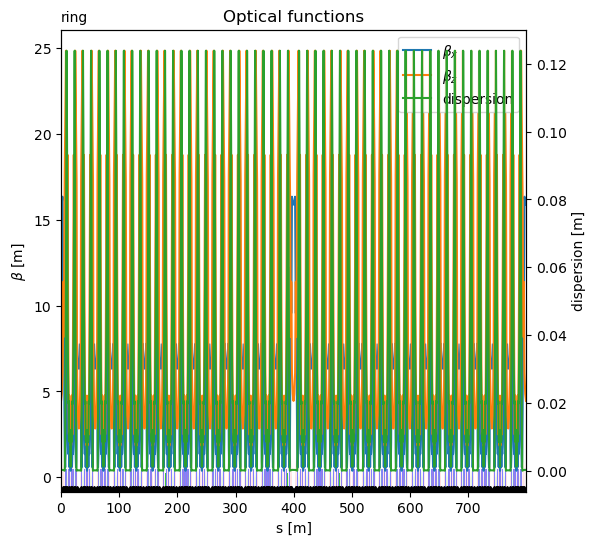

(<Axes: title={'left': 'ring', 'center': 'Optical functions'}, xlabel='s [m]', ylabel='$\\beta$ [m]'>,
 <Axes: ylabel='dispersion [m]'>,
 <Axes: >)

In [16]:
storage_ring_lattice.plot_beta()

In [17]:
storage_ring = at.load_mat('K4GSR_HBIv4-1.mat')

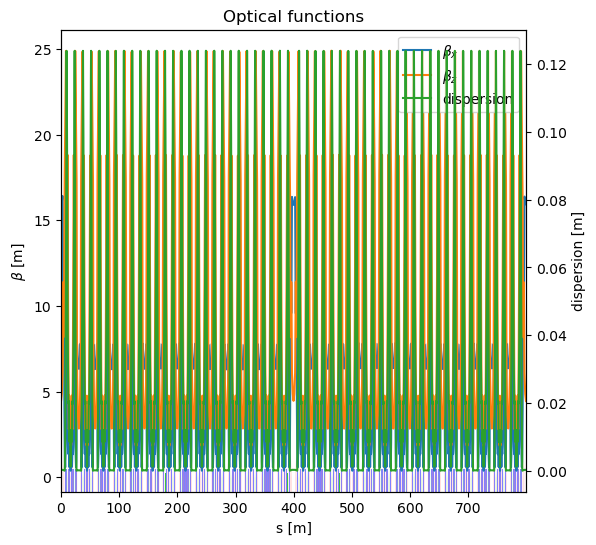

(<Axes: title={'center': 'Optical functions'}, xlabel='s [m]', ylabel='$\\beta$ [m]'>,
 <Axes: ylabel='dispersion [m]'>,
 <Axes: >)

In [18]:
storage_ring.plot_beta()

In [19]:
print(storage_ring_lattice)
print(storage_ring)

Lattice(<3780 elements>, name='ring', energy=np.float64(1000000000.0), particle=Particle('positron'), periodicity=1, beam_current=0.0, nbunch=1, use='ring')
Lattice(<3481 elements>, name='', energy=4000000000.0, particle=Particle('relativistic'), periodicity=1, harmonic_number=1332, beam_current=0.0, nbunch=1, in_file='/home/cspark/Work/projects/nkm/K4GSR_HBIv4-1.mat', use='THERING')


In [20]:
elemdata0, ringdata, elemdata = storage_ring.linopt6(range(len(storage_ring)+1))

In [21]:
elemdata['beta']

array([[15.93916713,  4.44491948],
       [15.93916713,  4.44491948],
       [16.41289627,  6.0876982 ],
       ...,
       [16.38015661,  6.08222777],
       [15.93916713,  4.44491948],
       [15.93916713,  4.44491948]])

Text(0, 0.5, '$\\beta$ [m]')

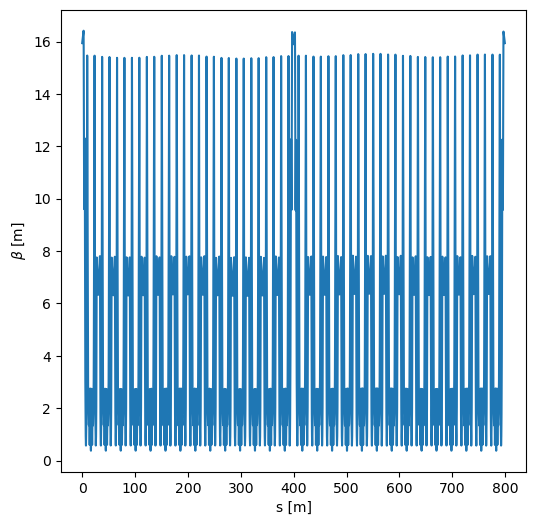

In [22]:
plt.plot(elemdata.s_pos, elemdata.beta[:,0])
plt.xlabel('s [m]')
plt.ylabel(r'$\beta$ [m]')

Text(0, 0.5, '$\\beta$ [m]')

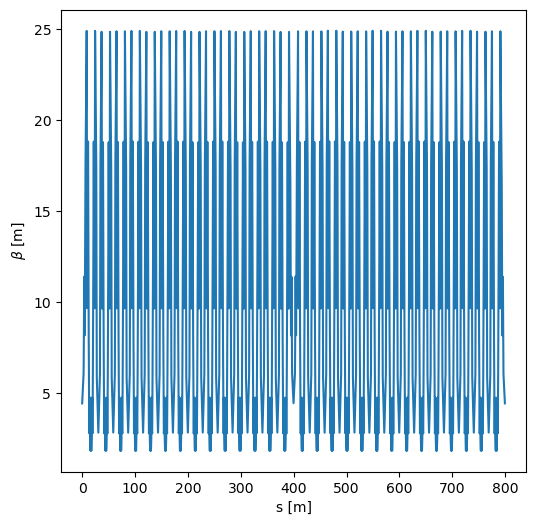

In [23]:
plt.plot(elemdata.s_pos, elemdata.beta[:,1])
plt.xlabel('s [m]')
plt.ylabel(r'$\beta$ [m]')

## Extract Lattice Functions at Injection

In [24]:
refpts0 = storage_ring.get_cells(at.checkname('LH1'))
print(list(storage_ring[refpts0]))
elemdata0, ringdata, elemdata = storage_ring_lattice.get_optics(refpts=refpts0)
print(elemdata0['beta'], elemdata0['alpha'], elemdata0['dispersion'])

[Drift('LH1', 2.7), Drift('LH1', 2.7), Drift('LH1', 2.7), Drift('LH1', 2.7)]
[15.89219566  4.44966838] [-1.27665924e-11 -1.55351767e-10] [ 3.26686576e-04 -2.74244120e-17  0.00000000e+00  0.00000000e+00]


### Get Acceptance at QH1

In [25]:
refpts1 = storage_ring.get_cells(at.checkname('QH1'))
qh1_indices = np.where(refpts1)[0]
refpts1[qh1_indices] = False
refpts1[qh1_indices[0]] = True
#refpts1[qh1_indices[1]] = True

storage_ring[[refpts1]]

Lattice([Quadrupole('QH1', 0.2, np.float64(1.283948))], name='', energy=4000000000.0, particle=Particle('relativistic'), periodicity=1, harmonic_number=1332, beam_current=0.0, nbunch=1)

In [26]:
npoints = (100, 100)  # Number of points in horizontal and vertical directions
amplitudes = (0.008, 0.008)  # Maximum amplitude in [m] 
nturns = 500  # Number of turns for tracking to determine stability

# Step 4: Compute the horizontal acceptance at the selected reference point
# Use the `get_acceptance` function to obtain the stable region in the horizontal plane ('x' and 'xp')
boundary, survived, tracked =  = storage_ring.get_acceptance(
    planes=['x', 'xp'],
    npoints=npoints,
    amplitudes=amplitudes,
    #refpts=[refpts1],  # Pass the reference point as a list
    nturns=nturns,
    use_mp=False
)


8 cpu found for acceptance calculation
Single process acceptance calculation selected...
Consider use_mp=True for parallelized computations
The estimated load for grid mode is 10000.0
The estimated load for recursive mode is 1400.0
GridMode.RECURSIVE is recommended

Running grid boundary search:
Element SectionStart, obspt=0
The grid mode is GridMode.RADIAL
The planes are ['x' 'xp']
Number of steps are [100 100]
The maximum amplitudes are [0.008 0.008]
The maximum boundaries are ((np.float64(1e-06), np.float64(1.0)), (np.float64(3.141592653589793), np.float64(0.0)))
1/1: Projecting obs=(SectionStart, 0) to the start of the ring, the initial offset is [ 6.38414587e-09 -4.47910481e-09  0.00000000e+00  0.00000000e+00
  9.63889554e-06  3.60657976e-04] with dp=0.0
Starting the multi-turn tracking...
Calculation took 1009.2923176288605


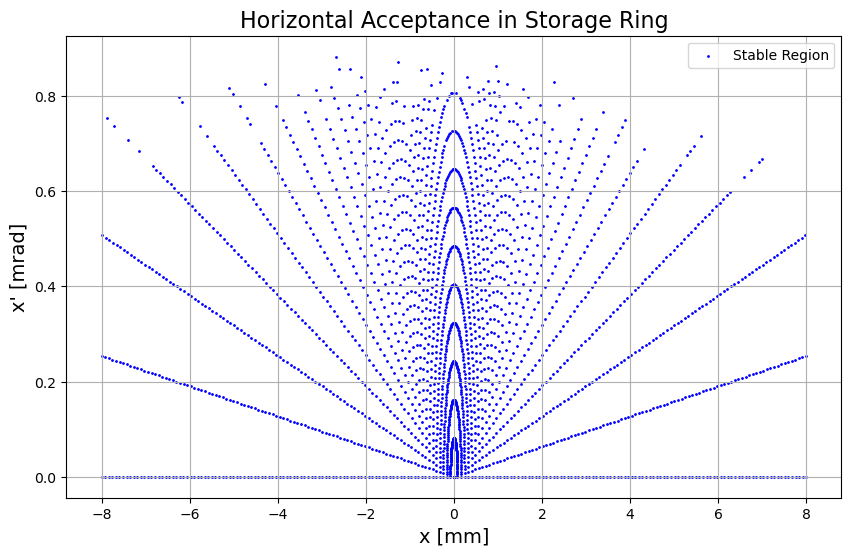

In [32]:
boundary, survived, tracked = acceptance_results
x_coords_survived = survived[0, :]
xp_coords_survived = survived[1, :]

plt.figure(figsize=(10, 6))
plt.scatter(x_coords_survived*1e3, xp_coords_survived*1e3, s=1, color='b', label='Stable Region')
plt.xlabel('x [mm]', fontsize=14)
plt.ylabel("x' [mrad]", fontsize=14)
plt.title('Horizontal Acceptance in Storage Ring', fontsize=16)
plt.grid(True)
plt.legend()

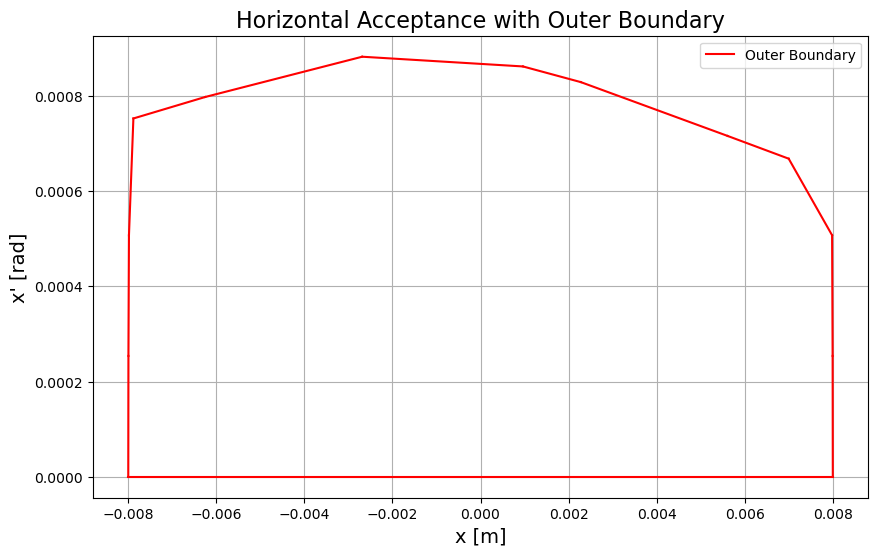

In [37]:
plt.figure(figsize=(10, 6))
#plt.scatter(x_coords_survived, xp_coords_survived, s=1, color='b', label='Stable Region')

# Step 7: Calculate and plot the convex hull (outer boundary)
points = np.vstack((x_coords_survived, xp_coords_survived)).T  # Create a 2D array of points (x, xp)
hull = ConvexHull(points)

# Plot the convex hull by connecting the vertices
for simplex in hull.simplices:
    plt.plot(points[simplex, 0], points[simplex, 1], 'r-', linewidth=1.5, label='Outer Boundary' if simplex[0] == hull.simplices[0, 0] else "")

# Set plot labels and title
plt.xlabel('x [m]', fontsize=14)
plt.ylabel("x' [rad]", fontsize=14)
plt.title('Horizontal Acceptance with Outer Boundary', fontsize=16)
plt.grid(True)
plt.legend()

In [34]:
# Step 6: Plot the acceptance region
plt.figure(figsize=(10, 6))
plt.scatter(x_coords[stable_points], xp_coords[stable_points], s=1, color='b', label='Stable Region')
plt.xlabel('x [m]', fontsize=14)
plt.ylabel("x' [rad]", fontsize=14)
plt.title('Horizontal Acceptance at Reference Point (First QH1)', fontsize=16)
plt.grid(True)
plt.legend()

NameError: name 'x_coords' is not defined

<Figure size 1000x600 with 0 Axes>

In [13]:
# List of lattice elements
index = 0
for elem in storage_ring:
    if elem.FamName == 'LH1':
        print(index, elem)
    #print(index, elem.FamName)
    index += 1

1 Drift:
       FamName: LH1
        Length: 2.7
    PassMethod: DriftPass
1738 Drift:
       FamName: LH1
        Length: 2.7
    PassMethod: DriftPass
1741 Drift:
       FamName: LH1
        Length: 2.7
    PassMethod: DriftPass
3479 Drift:
       FamName: LH1
        Length: 2.7
    PassMethod: DriftPass
